### ✅ Step 1: Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [12]:
# show all columns
pd.set_option('display.max_column',None)

# present scientific notation (optional)
pd.set_option('display.float_format','{:.2f}'.format)

### 📥 Step 2: Load and Inspect Dataset

In [13]:
df = pd.read_csv(r"C:\Users\atulm\Desktop\Data Analytics\Python\Project\New folder\retail_sales_50k.csv")
df.head()

,Order_ID,Customer_ID,Gender,Age,Country,Product_Category,Quantity,Unit_Price,Discount,Order_Date,Payment_Method,Ad_Campaign,Returned,Total_Sales
0,10001,C00861,Male,40,Germany,Fashion,7,5232,0.00,2023-01-01 00:00:00.000000000,Credit Card,B,No,36624.00
1,10002,C03773,Female,32,India,Home,7,8563,0.00,2023-01-01 00:21:01.465229304,Debit Card,A,No,59941.00
2,10003,C03093,Male,28,India,Home,4,3369,0.10,2023-01-01 00:42:02.930458609,Debit Card,A,No,12128.40
3,10004,C00467,Female,38,UAE,Home,4,6796,0.10,2023-01-01 01:03:04.395687913,Debit Card,A,No,24465.60
4,10005,C04427,Male,56,UK,Groceries,7,2949,0.15,2023-01-01 01:24:05.860917218,COD,A,No,17546.55


In [14]:
# Quick look 
print("\nshape:",df.shape)
print("\ninfo:")
df.info()


shape: (50000, 14)

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          50000 non-null  int64  
 1   Customer_ID       50000 non-null  object 
 2   Gender            50000 non-null  object 
 3   Age               50000 non-null  int64  
 4   Country           50000 non-null  object 
 5   Product_Category  50000 non-null  object 
 6   Quantity          50000 non-null  int64  
 7   Unit_Price        50000 non-null  int64  
 8   Discount          50000 non-null  float64
 9   Order_Date        50000 non-null  object 
 10  Payment_Method    50000 non-null  object 
 11  Ad_Campaign       50000 non-null  object 
 12  Returned          50000 non-null  object 
 13  Total_Sales       50000 non-null  float64
dtypes: float64(2), int64(4), object(8)
memory usage: 5.3+ MB


In [15]:
# Summary Statistics
print('summary:')
df.describe()

summary:


,Order_ID,Age,Quantity,Unit_Price,Discount,Total_Sales
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,35000.50,38.50,5.00,5058.98,0.06,23590.88
std,14433.90,12.12,2.59,2857.42,0.07,19358.09
min,10001.00,18.00,1.00,100.00,0.00,89.60
25%,22500.75,28.00,3.00,2580.00,0.00,7671.90
50%,35000.50,39.00,5.00,5068.00,0.05,18160.10
75%,47500.25,49.00,7.00,7549.00,0.10,35309.10
max,60000.00,59.00,9.00,9999.00,0.20,89991.00


### 🧹 Step 3: Data Cleaning & Preprocessing

In [16]:
df["Order_Date"]

0        2023-01-01 00:00:00.000000000
1        2023-01-01 00:21:01.465229304
2        2023-01-01 00:42:02.930458609
3        2023-01-01 01:03:04.395687913
4        2023-01-01 01:24:05.860917218
                     ...              
49995    2024-12-30 22:35:54.139082784
49996    2024-12-30 22:56:55.604312088
49997    2024-12-30 23:17:57.069541392
49998    2024-12-30 23:38:58.534770696
49999    2024-12-31 00:00:00.000000000
Name: Order_Date, Length: 50000, dtype: object

In [17]:
# Change Format remove text unes..
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Order_Date"] = df["Order_Date"].dt.strftime("%Y-%m-%d")
df["Order_Date"]

0        2023-01-01
1        2023-01-01
2        2023-01-01
3        2023-01-01
4        2023-01-01
            ...    
49995    2024-12-30
49996    2024-12-30
49997    2024-12-30
49998    2024-12-30
49999    2024-12-31
Name: Order_Date, Length: 50000, dtype: object

In [18]:
# Check Missing Values 
print("\nMissing Values :\n")
df.isnull().sum()


Missing Values :



Order_ID            0
Customer_ID         0
Gender              0
Age                 0
Country             0
Product_Category    0
Quantity            0
Unit_Price          0
Discount            0
Order_Date          0
Payment_Method      0
Ad_Campaign         0
Returned            0
Total_Sales         0
dtype: int64

In [19]:
df.head()

,Order_ID,Customer_ID,Gender,Age,Country,Product_Category,Quantity,Unit_Price,Discount,Order_Date,Payment_Method,Ad_Campaign,Returned,Total_Sales
0,10001,C00861,Male,40,Germany,Fashion,7,5232,0.00,2023-01-01,Credit Card,B,No,36624.00
1,10002,C03773,Female,32,India,Home,7,8563,0.00,2023-01-01,Debit Card,A,No,59941.00
2,10003,C03093,Male,28,India,Home,4,3369,0.10,2023-01-01,Debit Card,A,No,12128.40
3,10004,C00467,Female,38,UAE,Home,4,6796,0.10,2023-01-01,Debit Card,A,No,24465.60
4,10005,C04427,Male,56,UK,Groceries,7,2949,0.15,2023-01-01,COD,A,No,17546.55


### 📊 Step 4: Univariate Analysis

In [21]:
columns = ['Year', 'Age', 'Gender', 'Country',
           'Product_Category', 'Quantity', 'Payment_Method', 'Ad_Campaign']

for col in columns:
    if col in df.columns:
        print(f"\nUnique Count of {col} Column -: {df[col].nunique()}")
        print("\nValue Counts of the Column -:\n", df[col].value_counts())
        print("\n--------------------------------------------------")
    else:
        print(f"\nColumn '{col}' not found in the DataFrame!")
        print("\n--------------------------------------------------")



Column 'Year' not found in the DataFrame!

--------------------------------------------------

Unique Count of Age Column -: 42

Value Counts of the Column -:
 Age
40    1284
18    1247
50    1241
28    1239
44    1236
54    1232
37    1219
32    1219
48    1217
56    1215
58    1214
29    1213
31    1211
33    1210
19    1207
39    1202
30    1201
55    1198
43    1189
47    1187
25    1185
34    1184
22    1180
57    1179
24    1173
51    1171
49    1170
26    1169
38    1168
46    1168
21    1167
20    1166
52    1166
35    1165
59    1163
27    1161
42    1157
53    1155
41    1152
23    1144
36    1143
45    1133
Name: count, dtype: int64

--------------------------------------------------

Unique Count of Gender Column -: 2

Value Counts of the Column -:
 Gender
Female    25114
Male      24886
Name: count, dtype: int64

--------------------------------------------------

Unique Count of Country Column -: 5

Value Counts of the Column -:
 Country
India      19877
UAE        10053

In [22]:
df.head(1)

,Order_ID,Customer_ID,Gender,Age,Country,Product_Category,Quantity,Unit_Price,Discount,Order_Date,Payment_Method,Ad_Campaign,Returned,Total_Sales
0,10001,C00861,Male,40,Germany,Fashion,7,5232,0.00,2023-01-01,Credit Card,B,No,36624.00


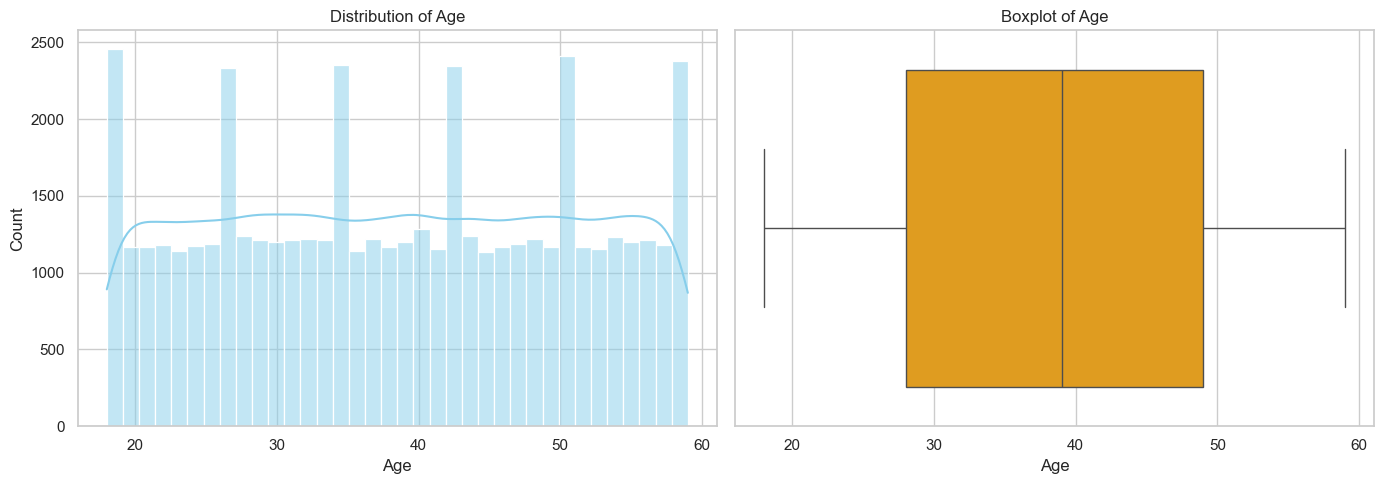

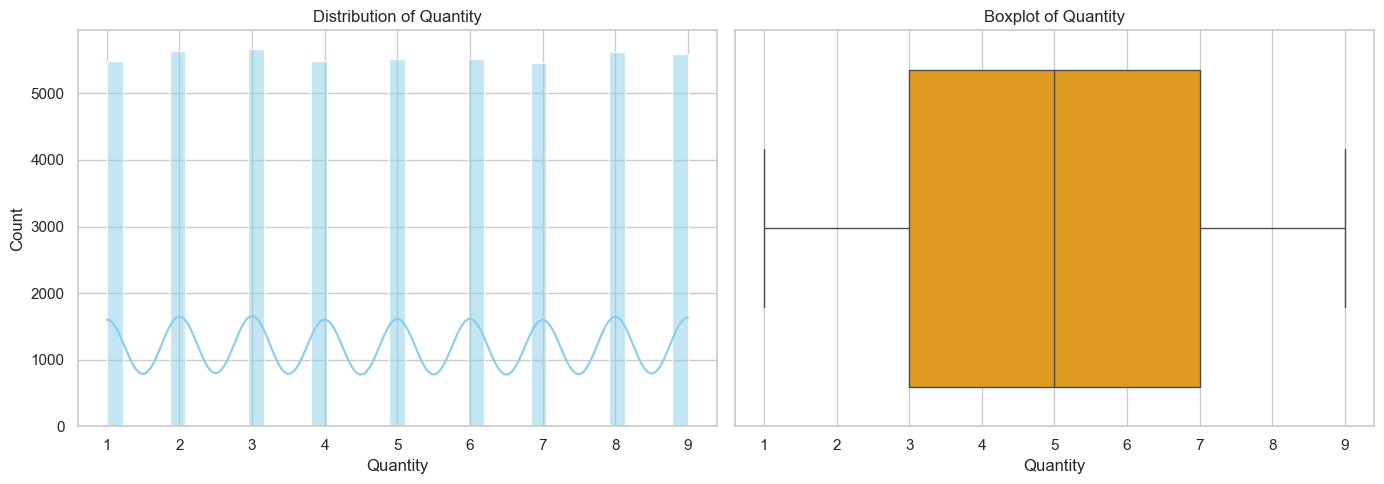

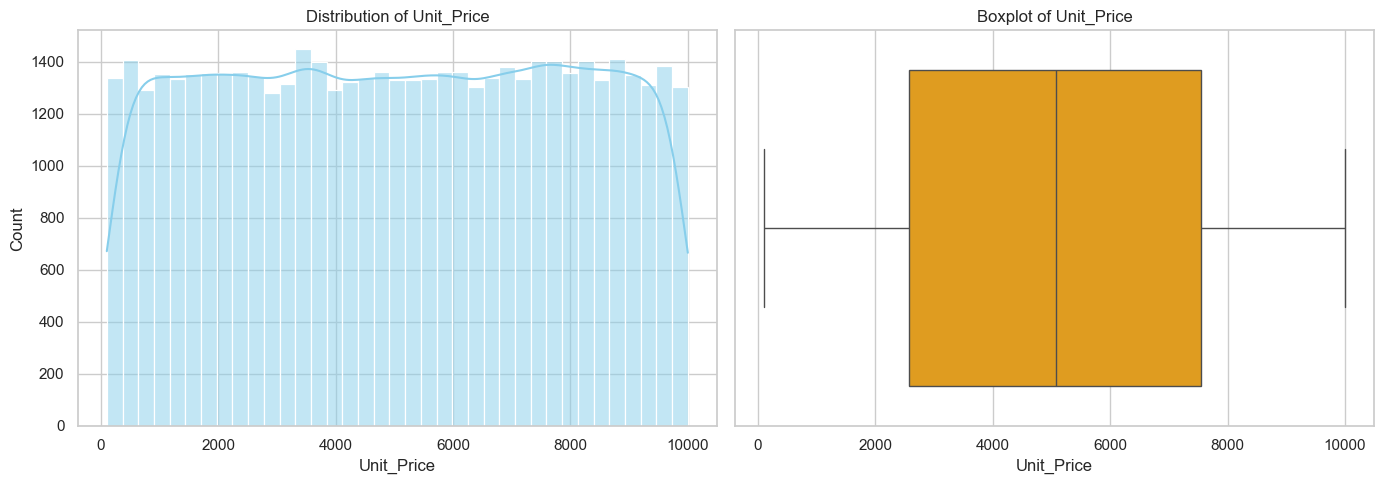

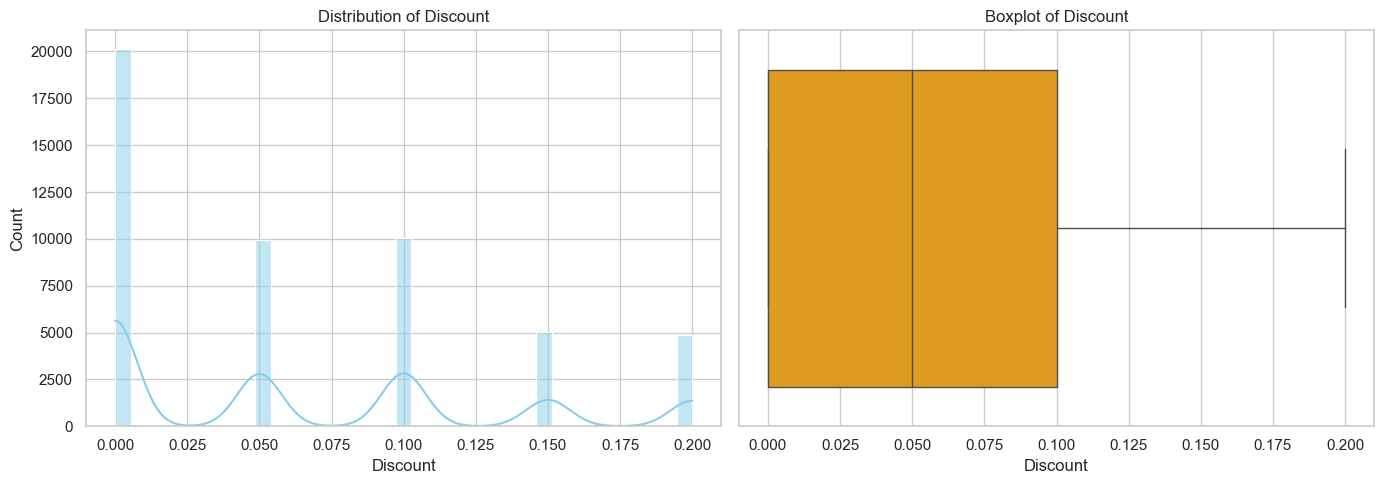

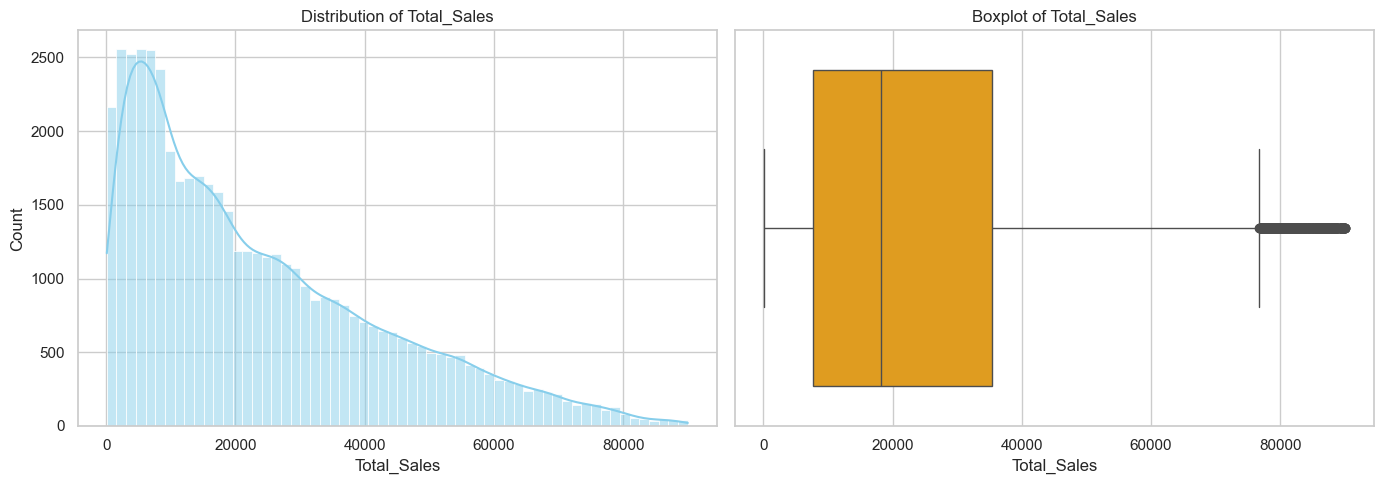

In [23]:
numerical_cols = ['Age', 'Quantity', 'Unit_Price', 'Discount', 'Total_Sales']

for col in numerical_cols:
    plt.figure(figsize=(14, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()


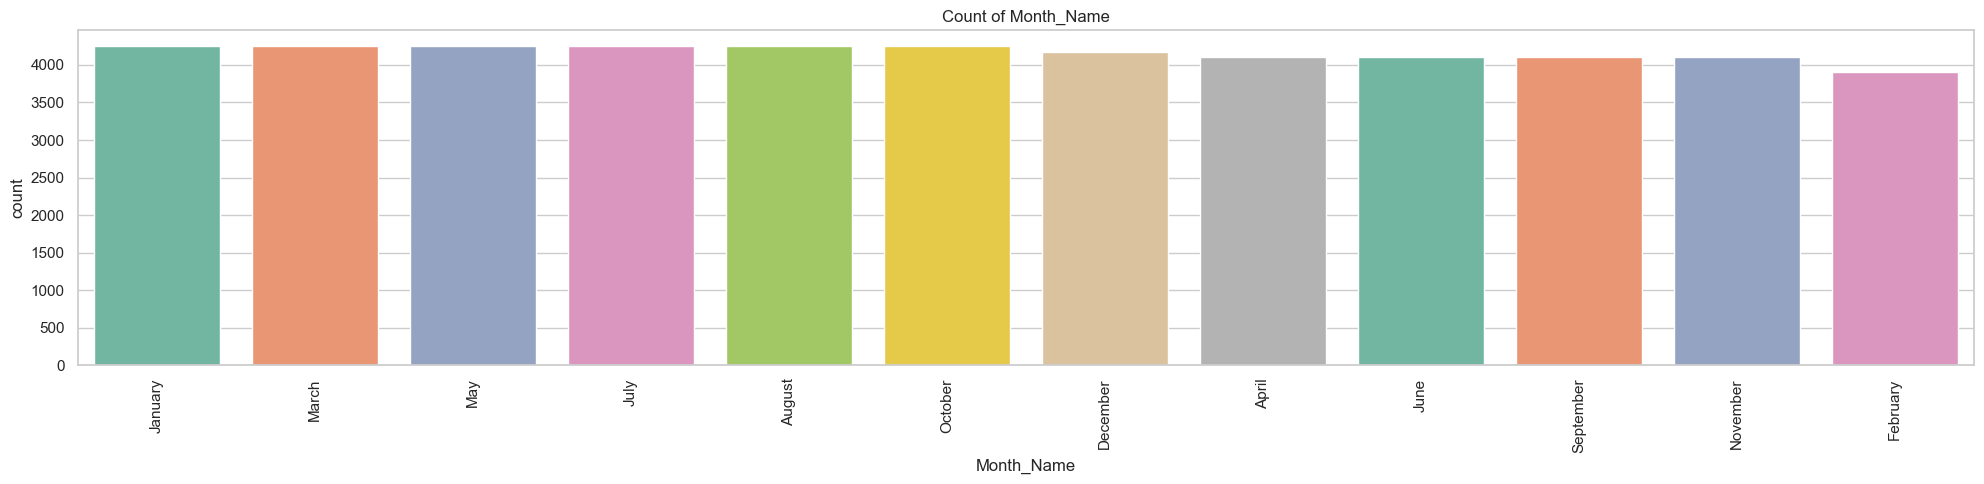

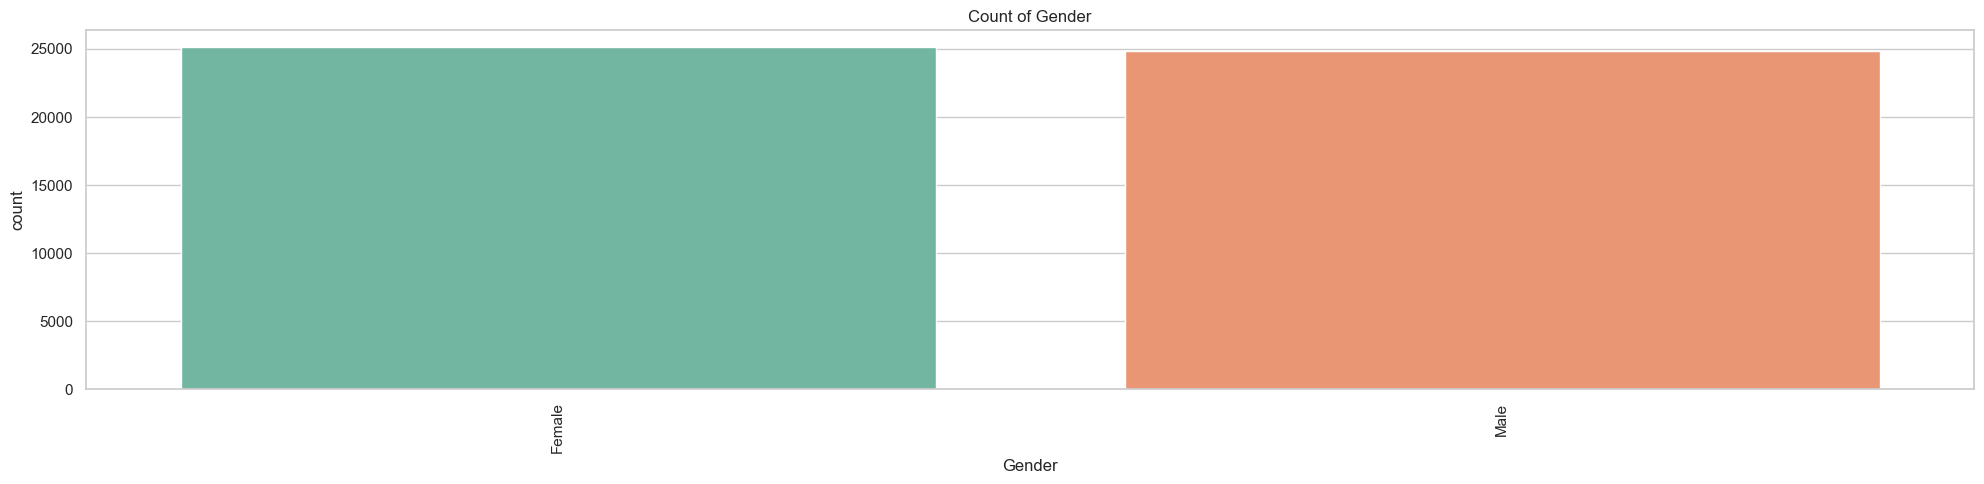

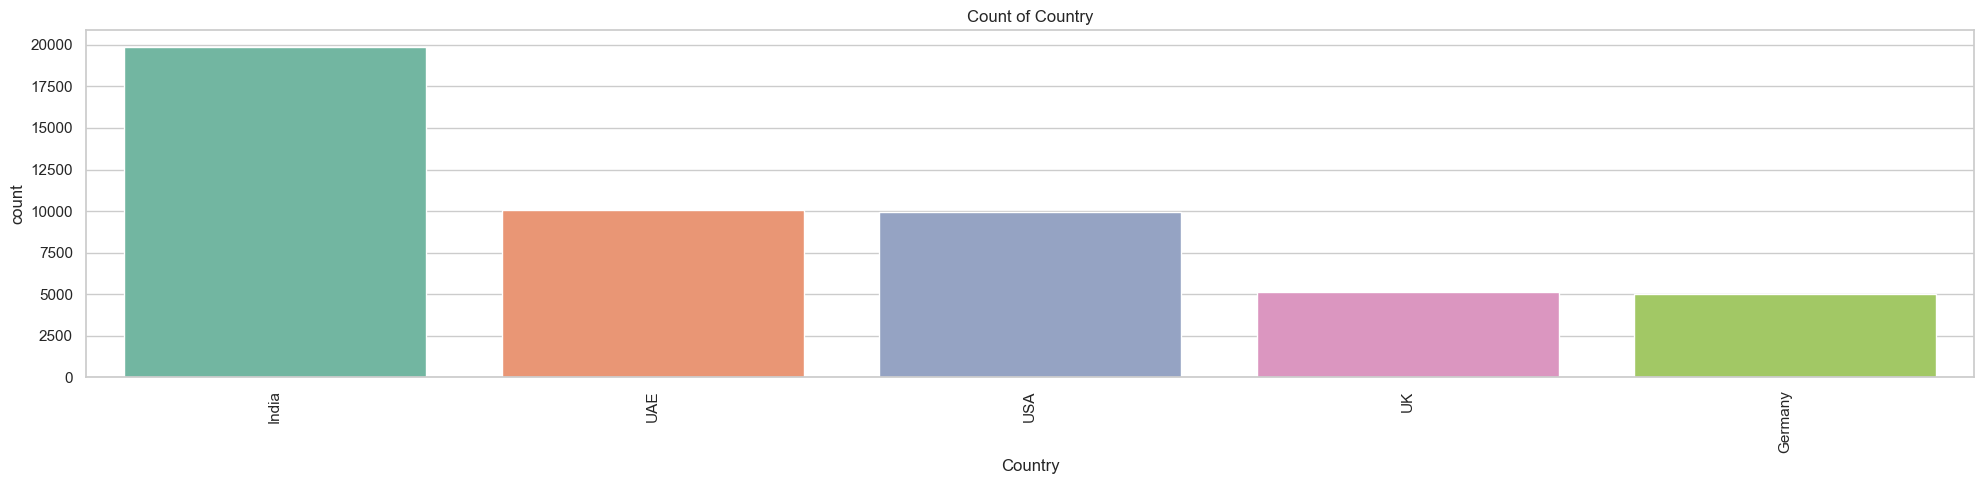

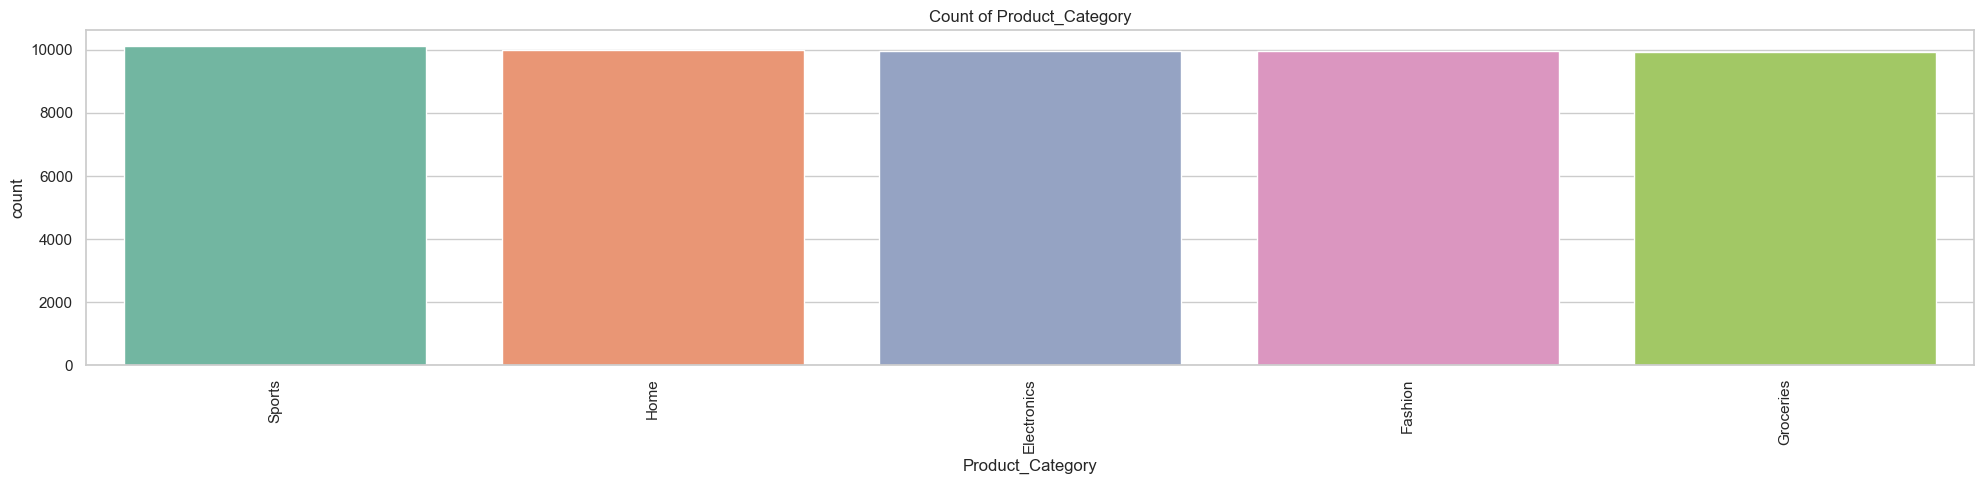

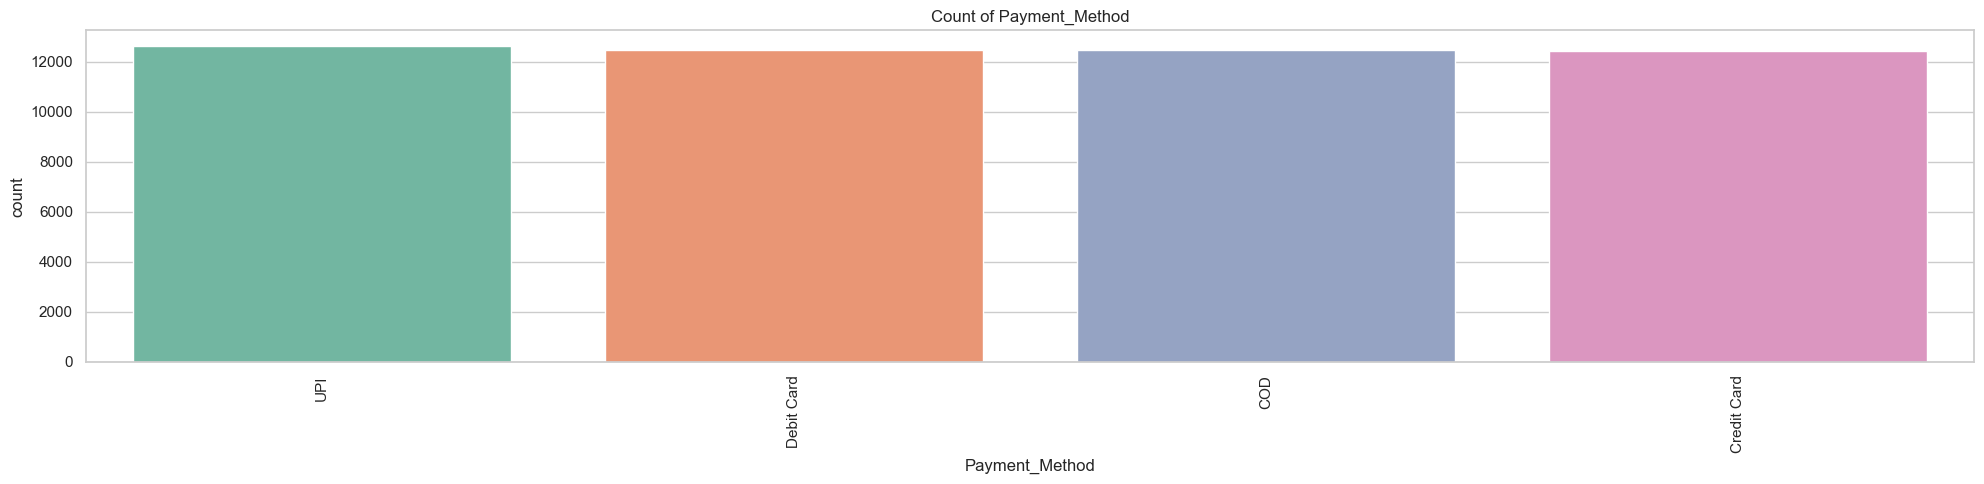

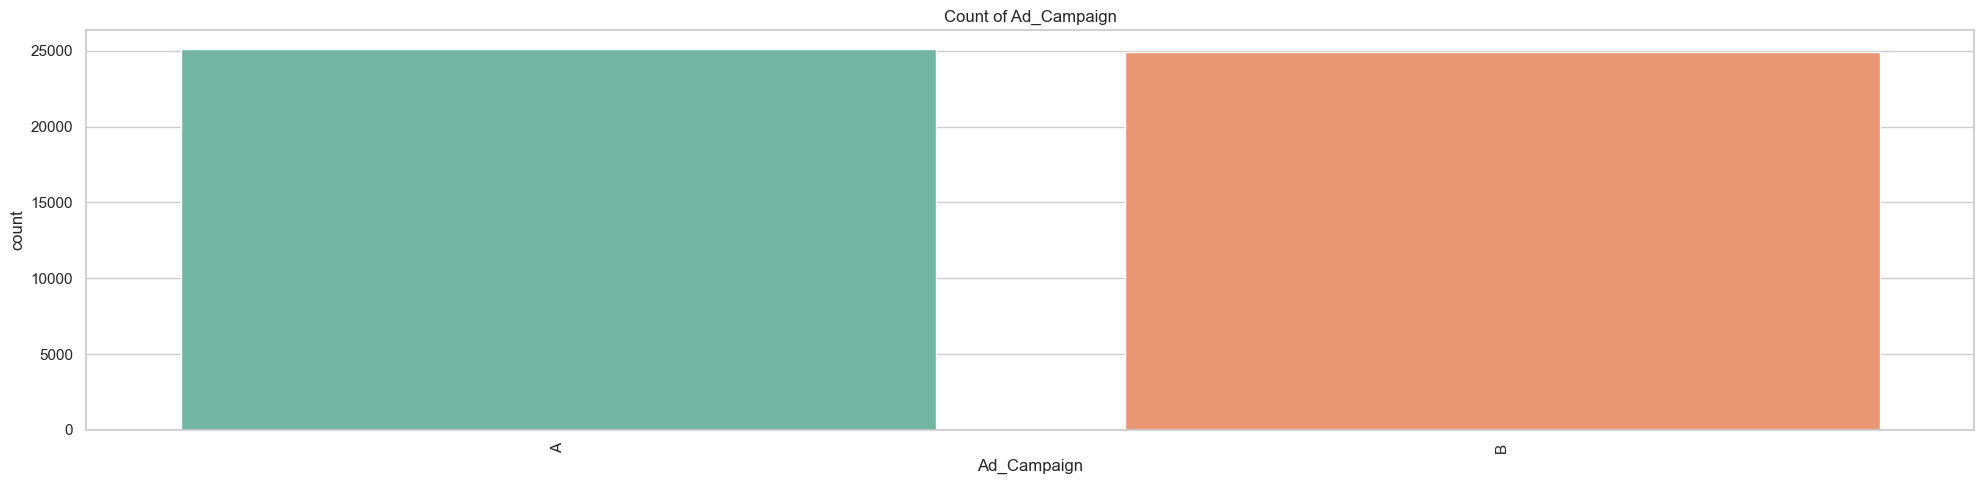

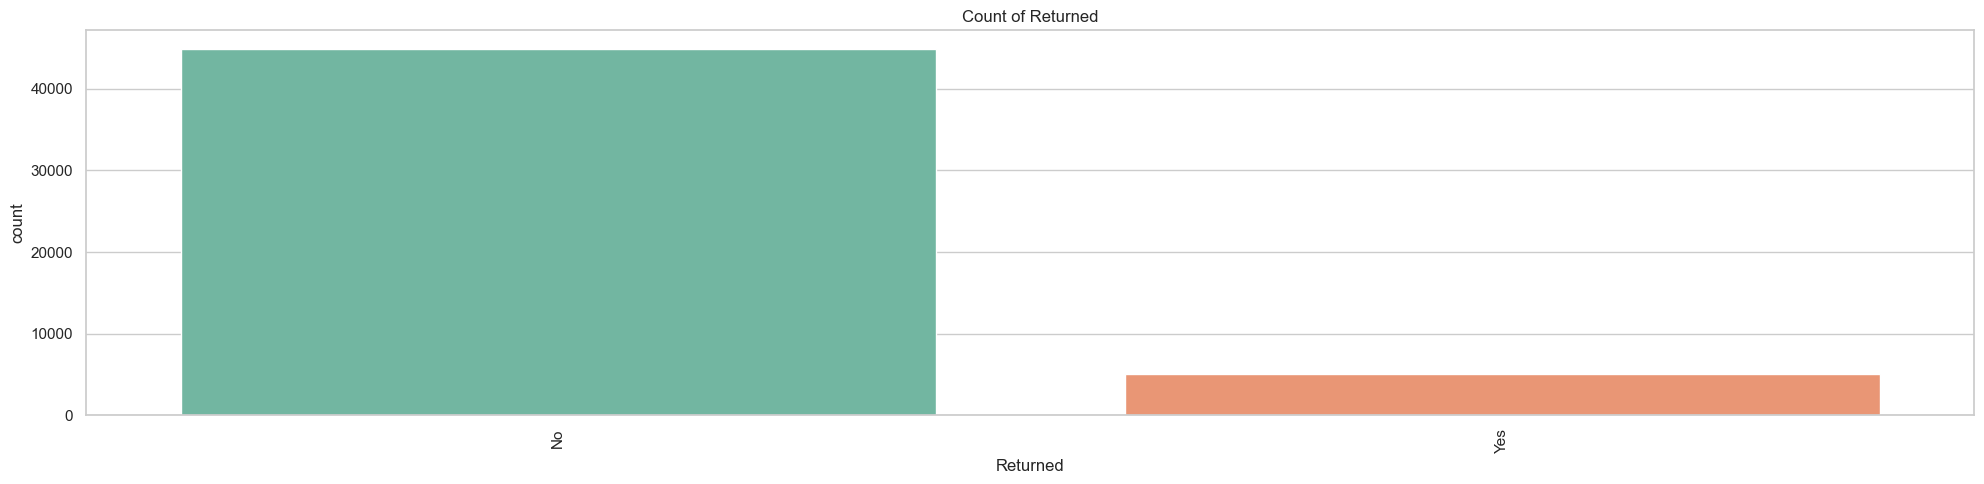

In [ ]:
categorical_cols = ['Month_Name', 'Gender', 'Country', 
                    'Product_Category', 'Payment_Method', 
                    'Ad_Campaign', 'Returned']

for col in categorical_cols:
    plt.figure(figsize=(20, 5))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index, palette='Set2')
    plt.xticks(rotation=90)
    plt.title(f'Count of {col}')
    plt.tight_layout()
    plt.show()


### 🔁 Step 5: Bivariate Analysis
👉 Definition:
Bivariate Analysis ka matlab hai do variables ke beech relationship ko samajhna.

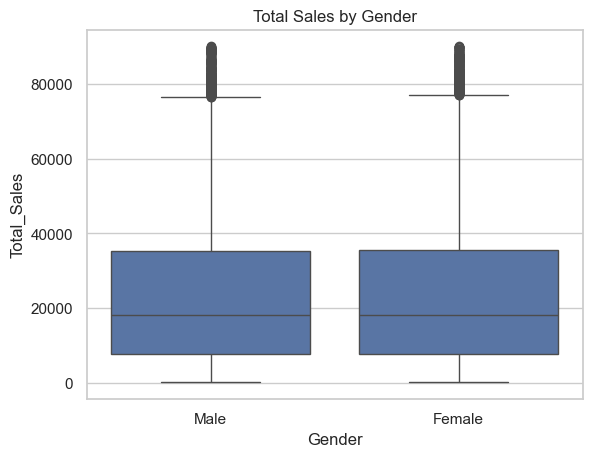

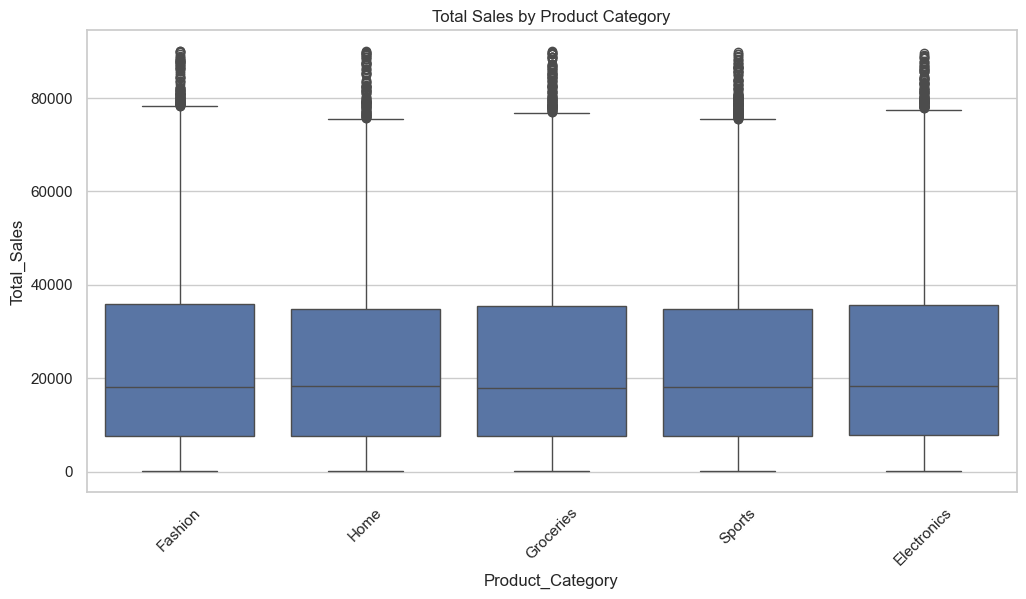

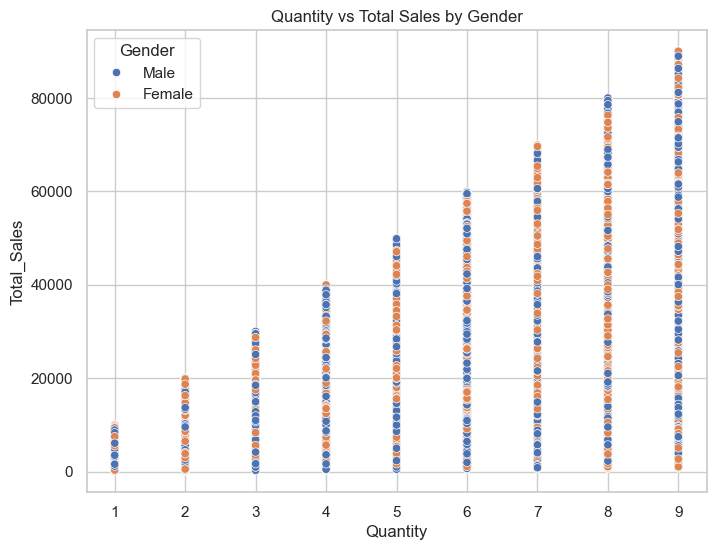

In [ ]:
# Revenue by Gender
sns.boxplot(x='Gender', y='Total_Sales', data=df)
plt.title('Total Sales by Gender')
plt.show()

# Revenue by Product Category
plt.figure(figsize=(12,6))
sns.boxplot(x='Product_Category', y='Total_Sales', data=df)
plt.xticks(rotation=45)
plt.title('Total Sales by Product Category')
plt.show()

# Quantity vs Revenue (Scatter)
plt.figure(figsize=(8,6))
sns.scatterplot(x='Quantity', y='Total_Sales', data=df, hue='Gender')
plt.title("Quantity vs Total Sales by Gender")
plt.show()


- ✅ Top & bottom **products by total revenue**
- ✅ Top & bottom **products by total quantity sold**
- ✅ Top & bottom **products by total profit** (assuming `Profit = Revenue - Cost`)

## 🏆 Top & Bottom Products Analysis – Full Code


In [ ]:
df.head(1)

,Order_ID,Customer_ID,Gender,Age,Country,Product_Category,Quantity,Unit_Price,Discount,Order_Date,Payment_Method,Ad_Campaign,Returned,Total_Sales,Year,Month_Name
0,10001,C00861,Male,40,Germany,Fashion,7,5232,0.00,2023-01-01,Credit Card,B,No,36624.00,2023,January


In [ ]:
# Step 1: Create Unit_Cost and Profit
df['Unit_Cost'] = df['Unit_Price'] * 0.7      # assume 70% cost
df['Profit'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity']

# Step 2: Group by Product_Category
product_perf = df.groupby('Product_Category').agg({
    'Quantity': 'sum',
    'Total_Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Profit', ascending=False)

# Step 3: Show the full performance table
print("\n📊 Product Performance Summary:")
print(product_perf)



📊 Product Performance Summary:
                  Quantity  Total_Sales      Profit
Product_Category                                   
Electronics          50168 238001936.80 76289367.30
Sports               50242 237584019.20 76223923.20
Fashion              49945 235476486.00 75491202.90
Home                 49915 234025872.70 75115932.30
Groceries            49777 234455479.45 75091210.80


In [ ]:
# Top 5 Products by Total Sales
top5_sales = product_perf.sort_values(by='Total_Sales', ascending=False).head(5)

print("🏆 Top 5 Products by Total Sales:")
print(top5_sales)


🏆 Top 5 Products by Total Sales:
                  Quantity  Total_Sales      Profit
Product_Category                                   
Electronics          50168 238001936.80 76289367.30
Sports               50242 237584019.20 76223923.20
Fashion              49945 235476486.00 75491202.90
Groceries            49777 234455479.45 75091210.80
Home                 49915 234025872.70 75115932.30


In [ ]:
# Bottom 5 Products by Total Sales (Revenue)
bottom_sales = product_perf.sort_values(by='Total_Sales', ascending=True).head(5)

print("\n📉 Bottom 5 Products by Total Sales:")
print(bottom_sales)



📉 Bottom 5 Products by Total Sales:
                  Quantity  Total_Sales      Profit
Product_Category                                   
Home                 49915 234025872.70 75115932.30
Groceries            49777 234455479.45 75091210.80
Fashion              49945 235476486.00 75491202.90
Sports               50242 237584019.20 76223923.20
Electronics          50168 238001936.80 76289367.30


In [ ]:
# Top 5 Products by Quantity Sold
top_quantity = product_perf.sort_values(by='Quantity', ascending=False).head(5)
print("\n📦 Top 5 Products by Quantity Sold:")
print(top_quantity)



📦 Top 5 Products by Quantity Sold:
                  Quantity  Total_Sales      Profit
Product_Category                                   
Sports               50242 237584019.20 76223923.20
Electronics          50168 238001936.80 76289367.30
Fashion              49945 235476486.00 75491202.90
Home                 49915 234025872.70 75115932.30
Groceries            49777 234455479.45 75091210.80


In [ ]:
# Bottom 5 Products by Quantity Sold
bottom_quantity = product_perf.sort_values(by='Quantity', ascending=True).head(5)
print("\n📦 Bottom 5 Products by Quantity Sold:")
print(bottom_quantity)



📦 Bottom 5 Products by Quantity Sold:
                  Quantity  Total_Sales      Profit
Product_Category                                   
Groceries            49777 234455479.45 75091210.80
Home                 49915 234025872.70 75115932.30
Fashion              49945 235476486.00 75491202.90
Electronics          50168 238001936.80 76289367.30
Sports               50242 237584019.20 76223923.20


In [ ]:
# Top 5 Products by Profit
top_profit = product_perf.sort_values(by='Profit', ascending=False).head(5)
print("\n🏆 Top 5 Products by Profit:")
print(top_profit)



🏆 Top 5 Products by Profit:
                  Quantity  Total_Sales      Profit
Product_Category                                   
Electronics          50168 238001936.80 76289367.30
Sports               50242 237584019.20 76223923.20
Fashion              49945 235476486.00 75491202.90
Home                 49915 234025872.70 75115932.30
Groceries            49777 234455479.45 75091210.80


In [ ]:
# Bottom 5 Products by Profit
bottom_profit = product_perf.sort_values(by='Profit', ascending=True).head(5)
print("\n🔻 Bottom 5 Products by Profit:")
print(bottom_profit)



🔻 Bottom 5 Products by Profit:
                  Quantity  Total_Sales      Profit
Product_Category                                   
Groceries            49777 234455479.45 75091210.80
Home                 49915 234025872.70 75115932.30
Fashion              49945 235476486.00 75491202.90
Sports               50242 237584019.20 76223923.20
Electronics          50168 238001936.80 76289367.30


In [ ]:
# Category-wise Revenue/Profit Share
category_share = product_perf[['Total_Sales', 'Profit']].apply(lambda x: x/x.sum() * 100)
print(category_share)


                  Total_Sales  Profit
Product_Category                     
Electronics             20.18   20.17
Sports                  20.14   20.15
Fashion                 19.96   19.96
Home                    19.84   19.86
Groceries               19.88   19.85


In [ ]:
# Revenue vs Quantity Correlation
product_perf[['Quantity','Total_Sales','Profit']].corr()


,Quantity,Total_Sales,Profit
Quantity,1.00,0.92,0.95
Total_Sales,0.92,1.00,0.99
Profit,0.95,0.99,1.00


In [ ]:
gender_perf = df.groupby('Gender').agg({
    'Total_Sales':'sum',
    'Profit':'sum'
})
print(gender_perf)


        Total_Sales       Profit
Gender                          
Female 594913301.40 190727994.90
Male   584630492.75 187483641.60


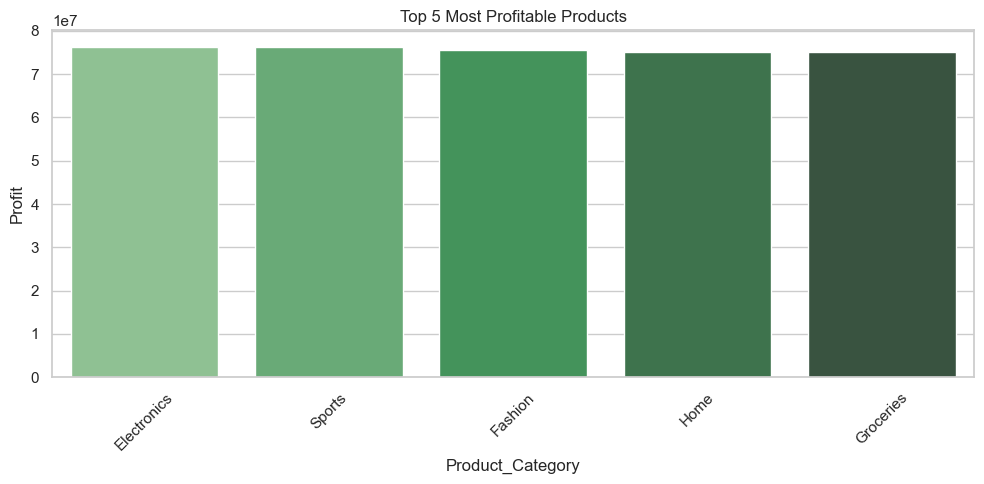

In [ ]:
# ✅ Top 5 Profitable Products
top_profit = product_perf.sort_values(by='Profit', ascending=False).head(5)
plt.figure(figsize=(10,5))
sns.barplot(x=top_profit.index, y=top_profit['Profit'], palette='Greens_d')
plt.title("Top 5 Most Profitable Products")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

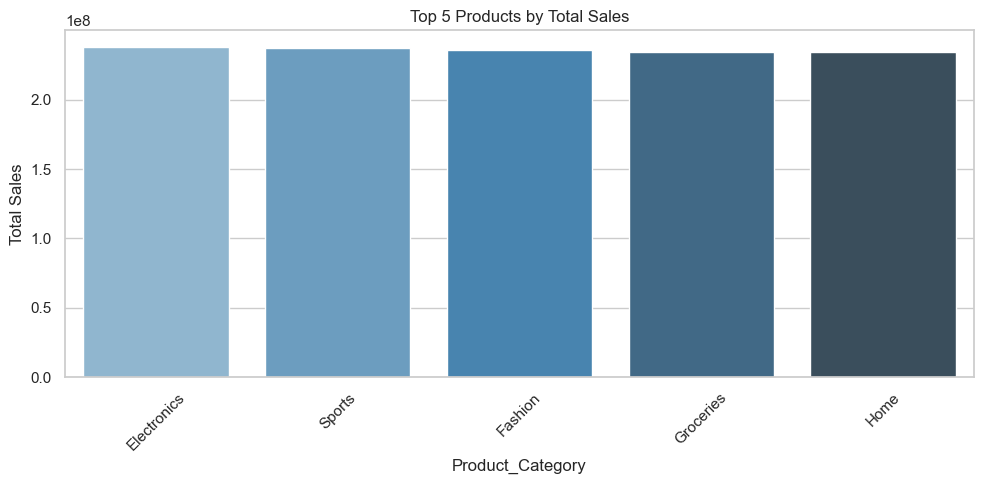

In [ ]:
# ✅ Top 5 Products by Total Sales
top_sales = product_perf.sort_values(by='Total_Sales', ascending=False).head(5)
plt.figure(figsize=(10,5))
sns.barplot(x=top_sales.index, y=top_sales['Total_Sales'], palette='Blues_d')
plt.title("Top 5 Products by Total Sales")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

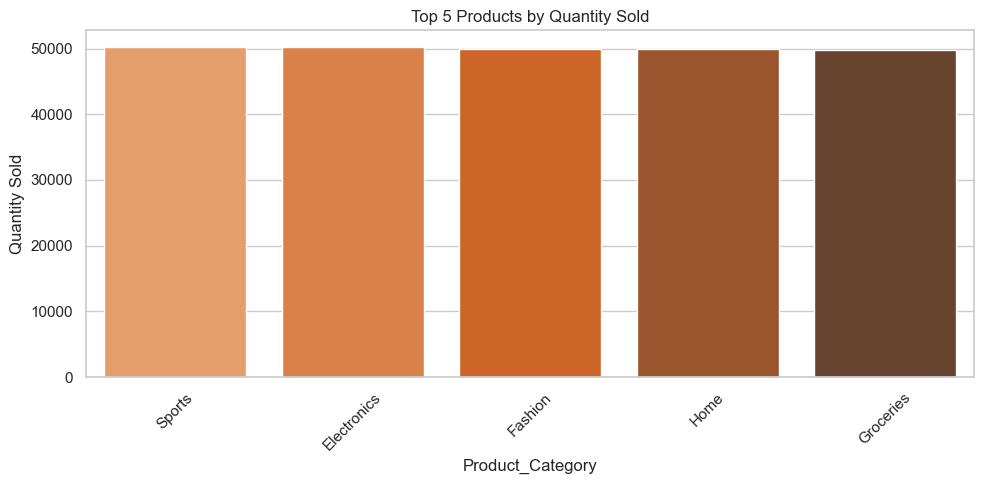

In [ ]:
# ✅ Top 5 Products by Quantity Sold
top_quantity = product_perf.sort_values(by='Quantity', ascending=False).head(5)
plt.figure(figsize=(10,5))
sns.barplot(x=top_quantity.index, y=top_quantity['Quantity'], palette='Oranges_d')
plt.title("Top 5 Products by Quantity Sold")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

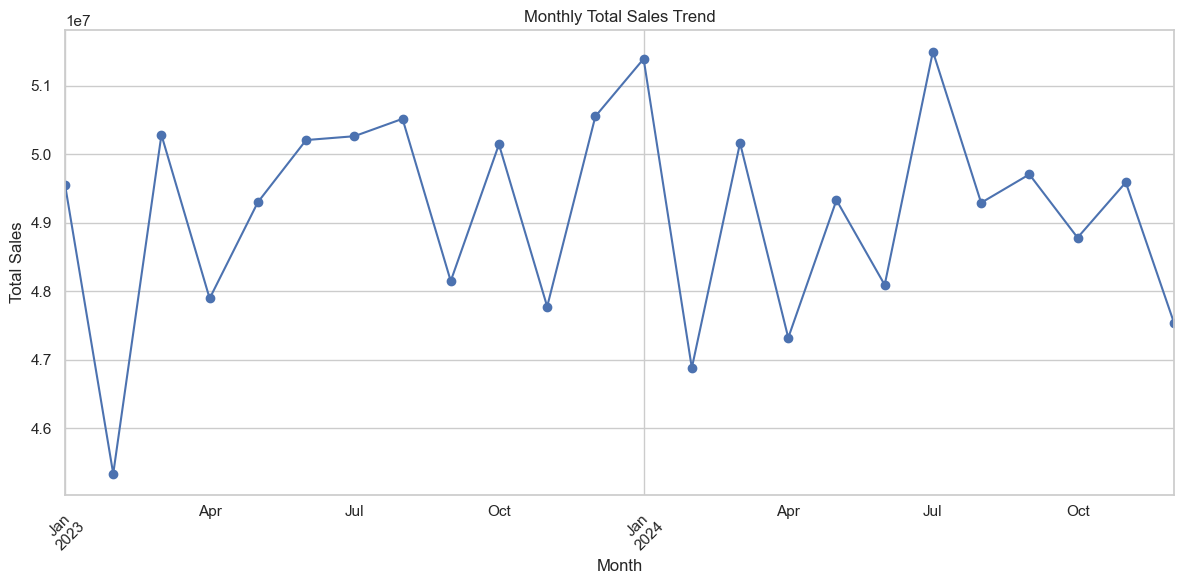

In [ ]:
# ✅ Monthly Total Sales Trend
df['Month_Year'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Month_Year')['Total_Sales'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title("Monthly Total Sales Trend")
plt.ylabel("Total Sales")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

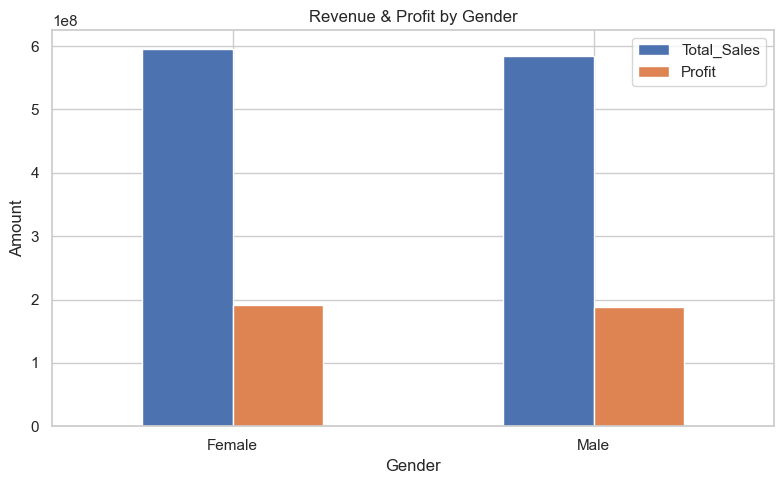

In [ ]:
gender_perf[['Total_Sales','Profit']].plot(kind='bar', figsize=(8,5))
plt.title("Revenue & Profit by Gender")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 🔀 Step 6: Multivariate Analysis

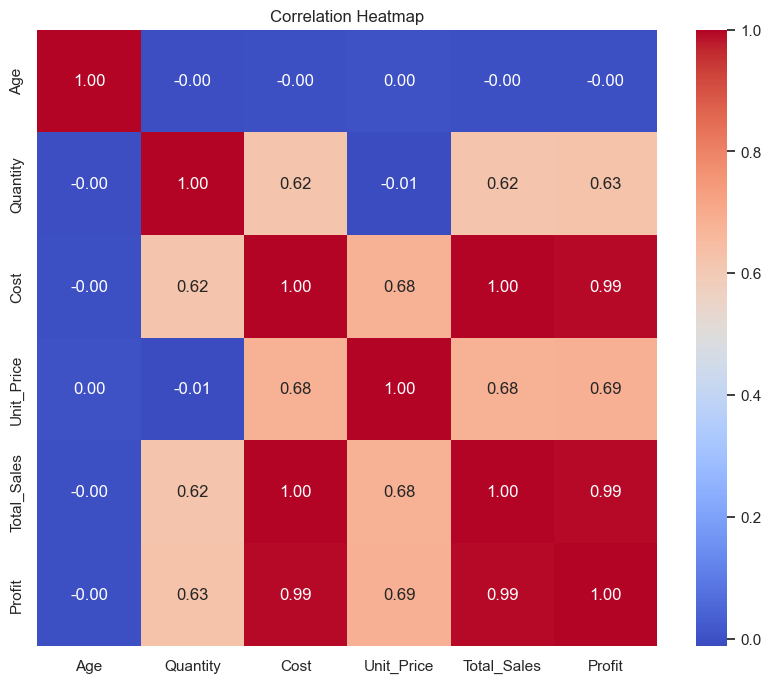

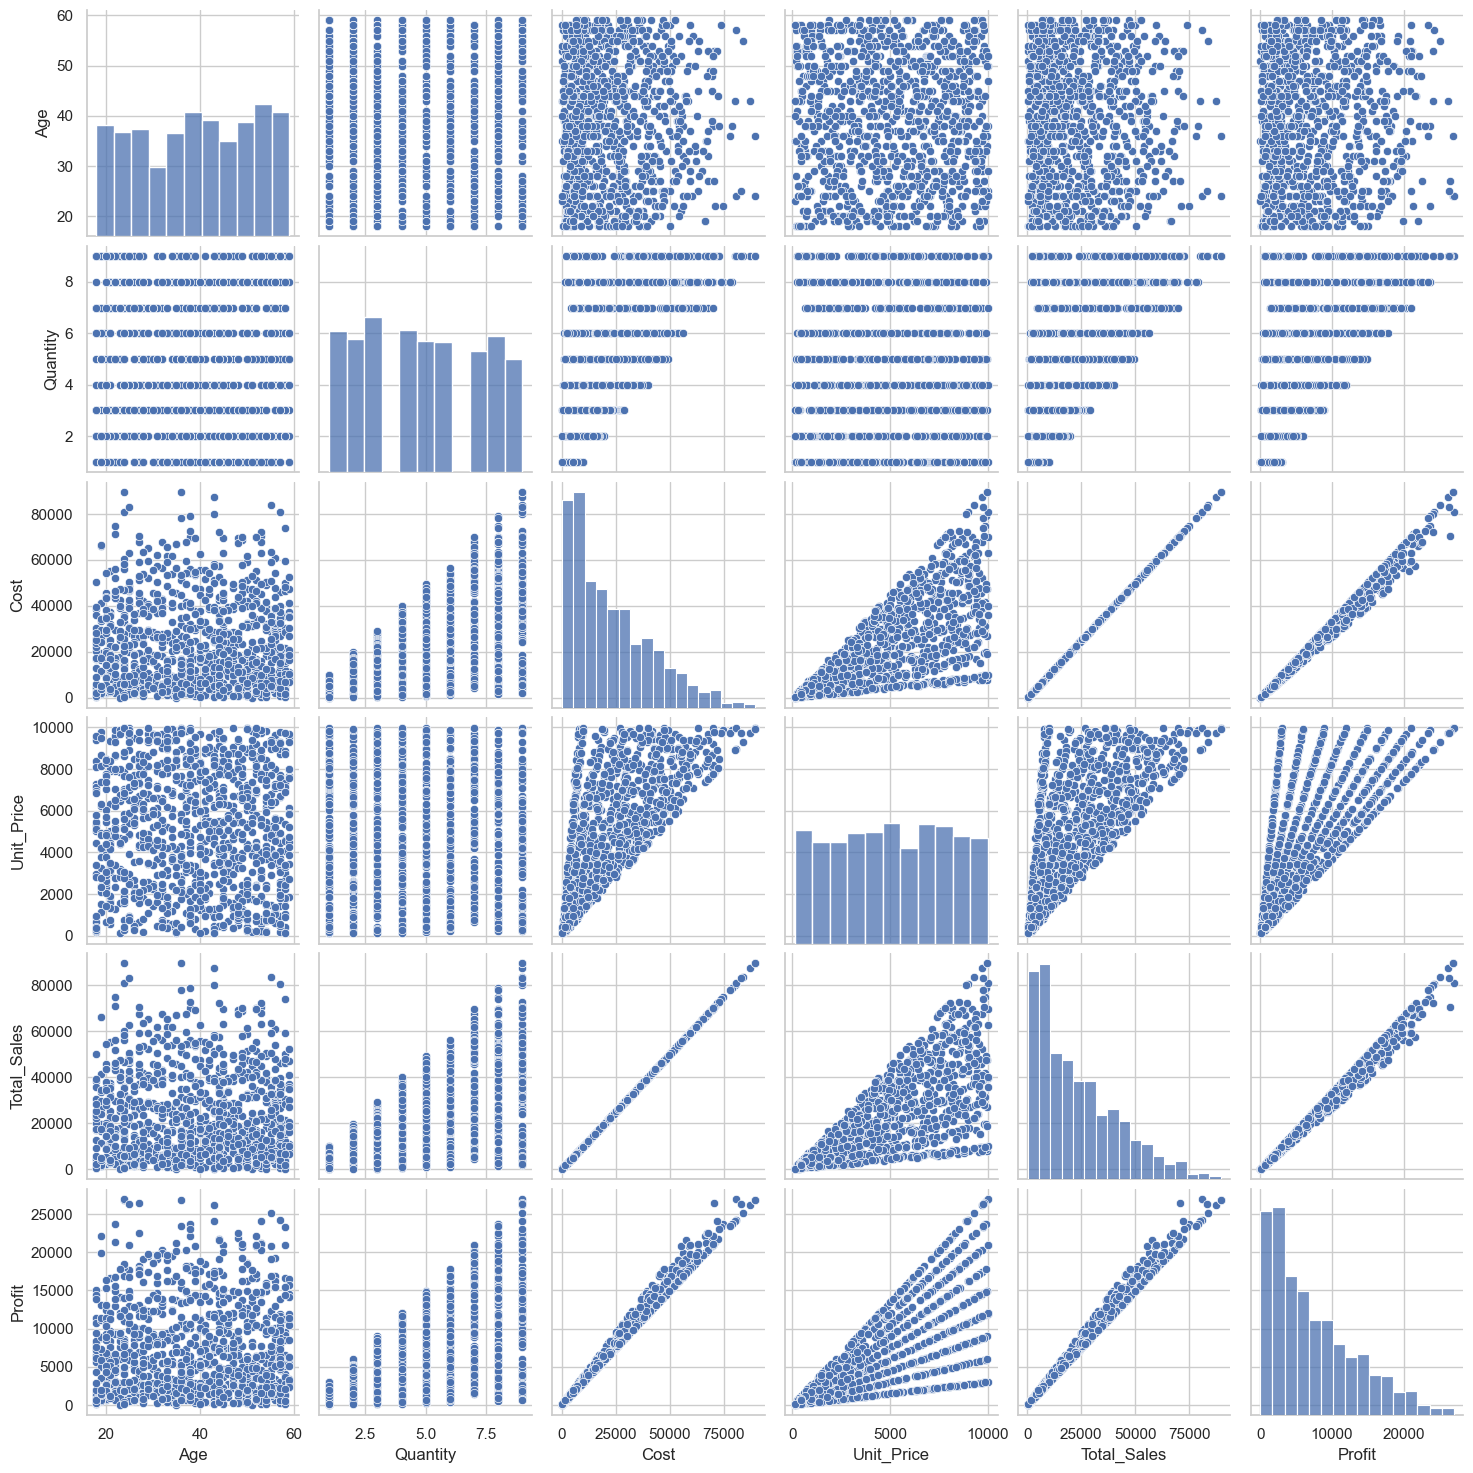

In [ ]:
# Numerical columns
numerical_cols = ['Age', 'Quantity', 'Cost', 'Unit_Price', 'Total_Sales', 'Profit']

# 1️⃣ Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 2️⃣ Pairplot (sample for large dataset)
sample_df = df[numerical_cols].sample(1000, random_state=1)  # 1000 random rows
sns.pairplot(sample_df)
plt.show()

### ✅ Step 7: Hypothesis Testing

In [ ]:
df.groupby('Gender')['Total_Sales'].agg(['sum','mean','max','min'])


,sum,mean,max,min
Gender,,,,
Female,594913301.40,23688.51,89991.00,97.85
Male,584630492.75,23492.34,89991.00,89.60


In [ ]:
# Male and Female Total_Sales
revenue_by_gender = df.groupby('Gender')['Total_Sales'].sum().reset_index()
revenue_by_gender


,Gender,Total_Sales
0,Female,594913301.40
1,Male,584630492.75


In [ ]:
# Grouping by Gender and Product_Category
subcat_by_gender = df.groupby(['Gender', 'Product_Category'])['Total_Sales'].sum().reset_index()
subcat_by_gender = subcat_by_gender.sort_values(by='Total_Sales', ascending=False)

# Ranking per Gender
subcat_by_gender["Rnk"] = subcat_by_gender.groupby('Gender')["Total_Sales"].rank(method='dense', ascending=False)

# Top 5 per Gender
top5_subcat_by_gender = subcat_by_gender[subcat_by_gender["Rnk"] <= 5].sort_values(by='Gender')
top5_subcat_by_gender


,Gender,Product_Category,Total_Sales,Rnk
0,Female,Electronics,120577510.10,1.00
4,Female,Sports,120082832.05,2.00
2,Female,Groceries,118984478.40,3.00
1,Female,Fashion,117639557.85,4.00
3,Female,Home,117628923.00,5.00
6,Male,Fashion,117836928.15,1.00
9,Male,Sports,117501187.15,2.00
5,Male,Electronics,117424426.70,3.00
8,Male,Home,116396949.70,4.00
7,Male,Groceries,115471001.05,5.00


In [ ]:
# Grouping by Gender and Product_Category
subcat_by_gender_qty = df.groupby(['Gender', 'Product_Category'])['Quantity'].sum().reset_index()
subcat_by_gender_qty = subcat_by_gender_qty.sort_values(by='Quantity', ascending=False)

# Ranking per Gender
subcat_by_gender_qty["Rnk"] = subcat_by_gender_qty.groupby('Gender')["Quantity"].rank(method='dense', ascending=False)

# Top 5 per Gender
top5_subcat_by_gender_qty = subcat_by_gender_qty[subcat_by_gender_qty["Rnk"] <= 5].sort_values(by='Gender')
top5_subcat_by_gender_qty


,Gender,Product_Category,Quantity,Rnk
0,Female,Electronics,25297,1.00
4,Female,Sports,25279,2.00
2,Female,Groceries,25141,3.00
1,Female,Fashion,24899,4.00
3,Female,Home,24854,5.00
8,Male,Home,25061,1.00
6,Male,Fashion,25046,2.00
9,Male,Sports,24963,3.00
5,Male,Electronics,24871,4.00
7,Male,Groceries,24636,5.00


In [ ]:
df['Year'].unique()


array([2023, 2024])

 Z-Test : Compare Revenue Of the Year 2023 and 2024

Null Hypothesis (H0): The revenue of the year 2023 is equal to the revenue  year 2024.  

Alternative Hypothesis (H1) : The revenue  2023 is different from 2024. 

In [ ]:
from scipy import stats

# Select revenue for each year
revenue_2023 = df[df['Year'] == 2023]['Total_Sales']
revenue_2024 = df[df['Year'] == 2024]['Total_Sales']

# Perform independent two-sample t-test
t_stat, p_value = stats.ttest_ind(revenue_2023, revenue_2024, equal_var=False)  # Welch’s t-test

print(f"T-Test Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject Null Hypothesis: Revenue in 2023 and 2024 is significantly different.")
else:
    print("Accept Null Hypothesis: No significant difference in revenue between 2023 and 2024.")


T-Test Statistic: 0.0904
P-Value: 0.9280
Accept Null Hypothesis: No significant difference in revenue between 2023 and 2024.


In [ ]:
df.groupby(by = "Year")["Total_Sales"].agg(['sum','mean','max','min'])

,sum,mean,max,min
Year,,,,
2023,589967593.95,23598.70,89991.00,96.30
2024,589576200.20,23583.05,89991.00,89.60


- Top-selling product per Year

In [ ]:
# Grouping by Year and Product_Category
Category_by_year = df.groupby(['Year', 'Product_Category'])['Quantity'].sum().reset_index()

# Rank categories per year
Category_by_year["Rnk"] = Category_by_year.groupby('Year')["Quantity"].rank(method='dense', ascending=False)

# Filter top 5 per year
top5_categories_per_year = Category_by_year[Category_by_year["Rnk"] <= 5].sort_values(by='Year')

# Show final table
top5_categories_per_year


,Year,Product_Category,Quantity,Rnk
0,2023,Electronics,24851,4.00
1,2023,Fashion,25150,2.00
2,2023,Groceries,25186,1.00
3,2023,Home,24885,3.00
4,2023,Sports,24839,5.00
5,2024,Electronics,25317,2.00
6,2024,Fashion,24795,4.00
7,2024,Groceries,24591,5.00
8,2024,Home,25030,3.00
9,2024,Sports,25403,1.00


In [ ]:
from scipy import stats

# ANOVA: Revenue by Product Category
anova_data = [group['Total_Sales'] for name, group in df.groupby('Product_Category')]
f_stat, p_val = stats.f_oneway(*anova_data)

print("ANOVA: Revenue by Product Category")
print(f"F-statistic = {f_stat:.4f}, P-value = {p_val:.4f}")

# Interpretation
if p_val < 0.05:
    print("Reject Null Hypothesis: Revenue significantly changed by Product Category")
else: 
    print("Accept Null Hypothesis: Revenue did not significantly change by Product Category")


ANOVA: Revenue by Product Category
F-statistic = 0.8026, P-value = 0.5233
Accept Null Hypothesis: Revenue did not significantly change by Product Category



- Chi-Square Test: Relationship Between Customer Gender and Product Category

Null Hypothesis (H0) : There is no relationship between customer gender and product category.  
Alternative Hypothesis (H1) : There is a significant relationship between customer gender and product category.  

In [ ]:
# Contingency table
contingency = pd.crosstab(df['Gender'], df['Product_Category'])
print("Contingency Table:\n", contingency)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-Value: {p:.4f}")

# Interpretation
if p < 0.05:
    print("✅ Reject Null Hypothesis: Gender and Product Category are dependent.")
else:
    print("✅ Accept Null Hypothesis: No significant relationship between Gender and Product Category.")


Contingency Table:
 Product_Category  Electronics  Fashion  Groceries  Home  Sports
Gender                                                         
Female                   4994     5015       4984  5017    5104
Male                     4979     4954       4963  4983    5007

Chi-Square Statistic: 0.4467
Degrees of Freedom: 4
P-Value: 0.9785
✅ Accept Null Hypothesis: No significant relationship between Gender and Product Category.


In [ ]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Gender', 'Age', 'Country',
       'Product_Category', 'Quantity', 'Unit_Price', 'Discount', 'Order_Date',
       'Payment_Method', 'Ad_Campaign', 'Returned', 'Total_Sales', 'Year',
       'Month_Name', 'Cost', 'Profit', 'Unit_Cost', 'Month_Year'],
      dtype='object')

In [ ]:
df[["Gender", "Product_Category"]].value_counts().unstack()


Product_Category,Electronics,Fashion,Groceries,Home,Sports
Gender,,,,,
Female,4994,5015,4984,5017,5104
Male,4979,4954,4963,4983,5007


### 📌 Business Insights & Recommendations  

**🛍️ Top Products (Revenue & Profit)**  
- Electronics (20.2%), Sports (20.1%), and Fashion (20.0%) together drive ~60% of total revenue.  
- **Recommendation:** Prioritize inventory allocation, promotional spend, and marketing focus on these categories.  

**📉 Underperforming Categories**  
- Home (19.8%) and Groceries (19.9%) contribute the least to overall revenue and profit.  
- **Recommendation:** Run targeted pricing/discount campaigns; if performance doesn’t improve, consider rationalizing SKUs.  

**👥 Customer Gender Insights**  
- Female customers generated **$594.9M**, slightly higher than males at **$584.6M**.  
- **Recommendation:** Develop gender-specific campaigns — loyalty programs for females, product bundling for males.  

**🗓️ Seasonality Trends**  
- Sales peak during **Nov–Dec** (festive season) and dip in **Mar–Apr**.  
- **Recommendation:** Increase stock levels and intensify promotions in festive months; optimize costs in low-demand periods.  

**📦 High Volume ≠ High Profitability**  
- Example: Groceries record high sales volume but deliver the lowest margin (~19.8% of profit).  
- **Recommendation:** Improve margins through pricing adjustments, product bundling, or promoting premium/high-value alternatives.  
